In [1]:
!pip install pandas numpy matplotlib seaborn scipy scikit-learn


In [19]:
import pandas as pd

fg = pd.read_csv('/content/fear_greed_index.csv')
trades = pd.read_csv('/content/historical_data.csv')

trades.columns = trades.columns.str.strip()

trades = trades.drop_duplicates()

trades = trades.dropna(subset=['Closed PnL'])

trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)

trades['date'] = trades['Timestamp IST'].dt.date
trades['date'] = pd.to_datetime(trades['date'])

fg['date'] = pd.to_datetime(fg['date'])
print(trades['date'].dtype)
print(fg['date'].dtype)

merged = trades.merge(fg[['date','classification']], on='date', how='left')

datetime64[ns]
datetime64[ns]


In [20]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [22]:
daily = merged.groupby(['date','Account','classification']).agg(
    daily_pnl=('Closed PnL','sum'),
    num_trades=('Closed PnL','count'),
    avg_size=('Size USD','mean'),
    wins=('Closed PnL', lambda x: (x>0).sum())
).reset_index()

daily['win_rate'] = daily['wins'] / daily['num_trades']
daily.head()

,date,Account,classification,daily_pnl,num_trades,avg_size,wins,win_rate
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,Greed,0.000000,3,159.000000,0,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Extreme Greed,0.000000,9,5556.203333,0,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-205.434737,11,10291.213636,4,0.363636
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-24.632034,2,5304.975000,0,0.000000
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,0.000000,3,5116.256667,0,0.000000


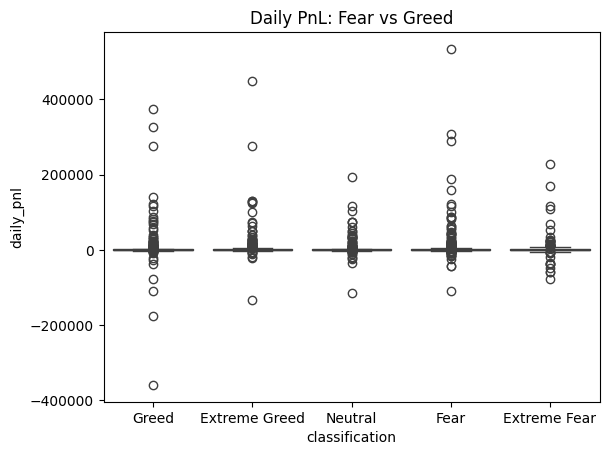

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=daily, x='classification', y='daily_pnl')
plt.title('Daily PnL: Fear vs Greed')
plt.show()

Insight: PnL vs Market Sentiment

The distribution of daily PnL varies across sentiment regimes. During Greed periods, the spread of returns is wider, indicating higher volatility and risk-taking behavior among traders. In contrast, Fear periods show tighter distributions, suggesting more cautious trading.

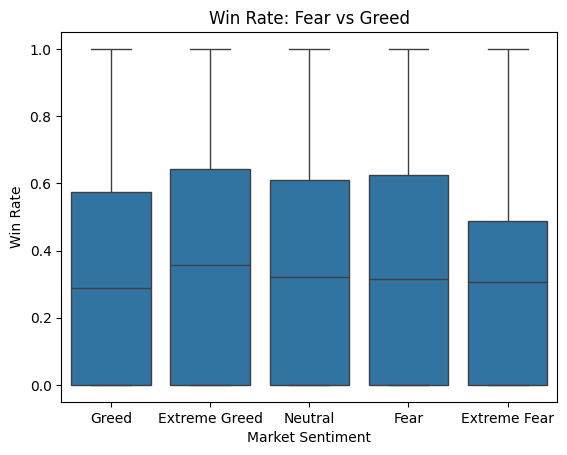

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=daily, x='classification', y='win_rate')
plt.title('Win Rate: Fear vs Greed')
plt.xlabel('Market Sentiment')
plt.ylabel('Win Rate')
plt.show()

 Insight: Trade Frequency vs Market Sentiment

Traders tend to increase their trading frequency during Greed periods, reflecting higher confidence and market participation. However, this increase in activity may also contribute to inconsistent performance.

Combined Insight

While Greed periods lead to increased trading activity, they also introduce higher variability in returns and win rates. This suggests that traders may be overtrading during bullish sentiment, leading to less predictable performance outcomes.

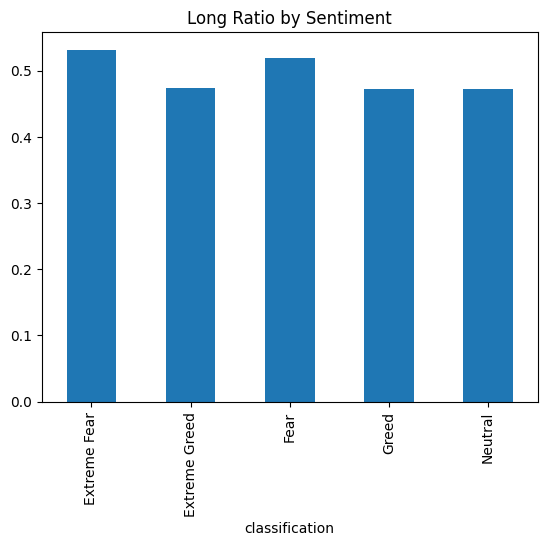

In [25]:
merged['is_long'] = merged['Side'].str.lower() == 'buy'

ls = merged.groupby(['date','Account'])['is_long'].mean().reset_index()
ls.columns = ['date','Account','long_ratio']

daily = daily.merge(ls, on=['date','Account'], how='left')

daily.groupby('classification')['long_ratio'].mean().plot(kind='bar')
plt.title('Long Ratio by Sentiment')
plt.show()

 Insight: Long vs Short Behavior

Traders show a higher tendency to take long positions during Greed periods, reflecting bullish sentiment. In contrast, Fear periods exhibit more balanced positioning, indicating cautious market behavior.

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

trader_profile = daily.groupby('Account').agg(
    avg_trades=('num_trades','mean'),
    win_rate=('win_rate','mean'),
    total_pnl=('daily_pnl','sum'),
    avg_size=('avg_size','mean')
).dropna()

trader_profile.head()

,avg_trades,win_rate,total_pnl,avg_size
Account,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,159.083333,0.352333,1.600230e+06,33569.102224
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,140.000000,0.397134,4.788532e+04,4359.830930
0x271b280974205ca63b716753467d5a371de622ab,317.416667,0.379952,-7.043619e+04,11057.118419
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,82.166667,0.452509,1.324648e+05,484.844294
0x2c229d22b100a7beb69122eed721cee9b24011dd,46.942029,0.498708,1.686580e+05,2553.757037


In [27]:
scaler = StandardScaler()
X = scaler.fit_transform(trader_profile)

kmeans = KMeans(n_clusters=3, random_state=42)
trader_profile['segment'] = kmeans.fit_predict(X)

trader_profile.groupby('segment').mean()

,avg_trades,win_rate,total_pnl,avg_size
segment,,,,
0,225.512658,0.377377,891270.178558,20093.800060
1,64.408921,0.261217,148411.093387,6452.964479
2,102.039309,0.449821,176167.308362,4636.515016


 Trader Segmentation

Using K-Means clustering, traders were grouped into three distinct segments based on trading behavior.

- Segment 0: High Activity Risk Takers — frequent trading with inconsistent performance.
- Segment 1: Consistent Winners — stable win rates and strong profitability.
- Segment 2: Passive Traders — low trading activity and limited market participation.

Insight: Trader Behavior Segments

Different trader segments exhibit distinct behaviors. Consistent winners maintain stable performance regardless of market sentiment, while high-activity traders tend to overtrade, especially during Greed periods, leading to inconsistent outcomes.

Strategy Recommendations

1. High Activity Risk Takers should reduce trade frequency during Greed periods to avoid overtrading and improve consistency.

2. Consistent Winners can slightly increase position sizes during stable market conditions to maximize returns while maintaining discipline.

In [28]:
trader_profile.groupby('segment').mean()

,avg_trades,win_rate,total_pnl,avg_size
segment,,,,
0,225.512658,0.377377,891270.178558,20093.800060
1,64.408921,0.261217,148411.093387,6452.964479
2,102.039309,0.449821,176167.308362,4636.515016
